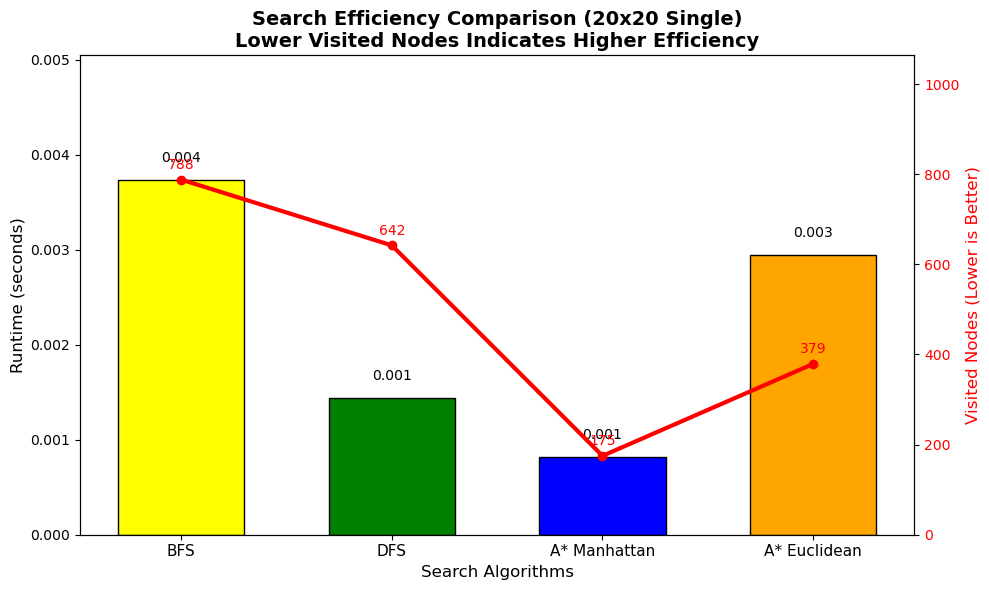

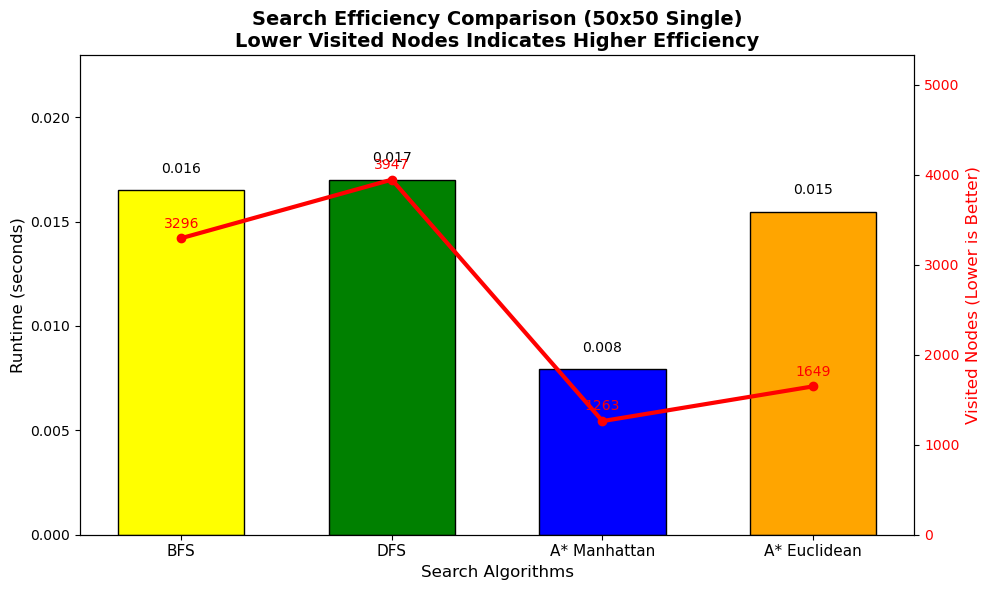

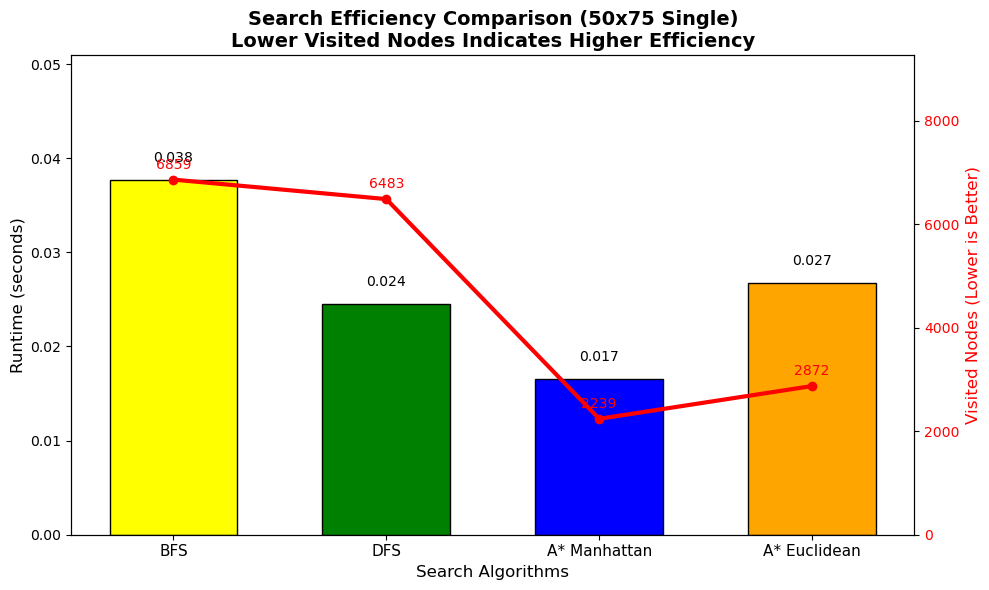

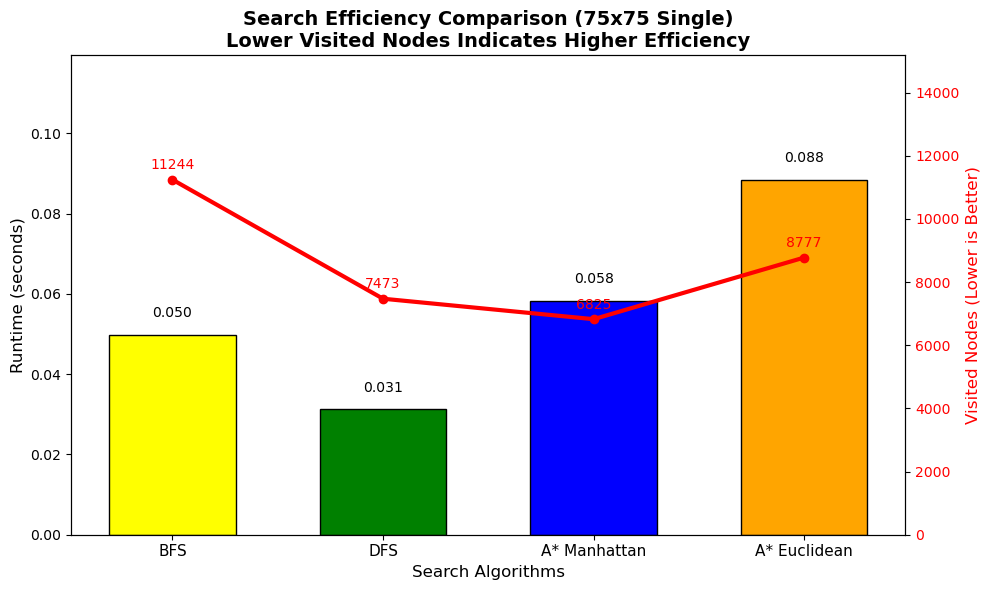

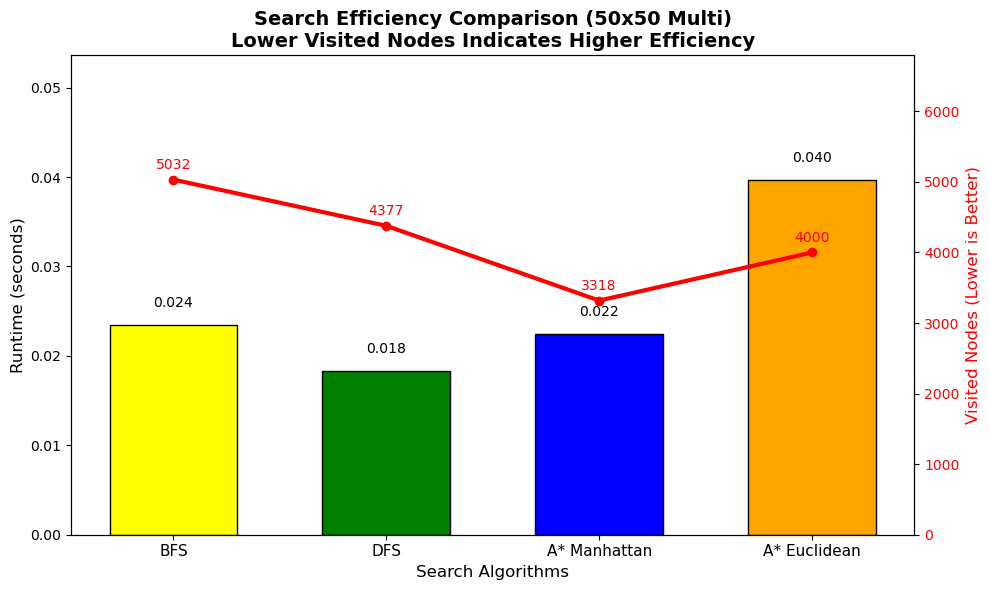

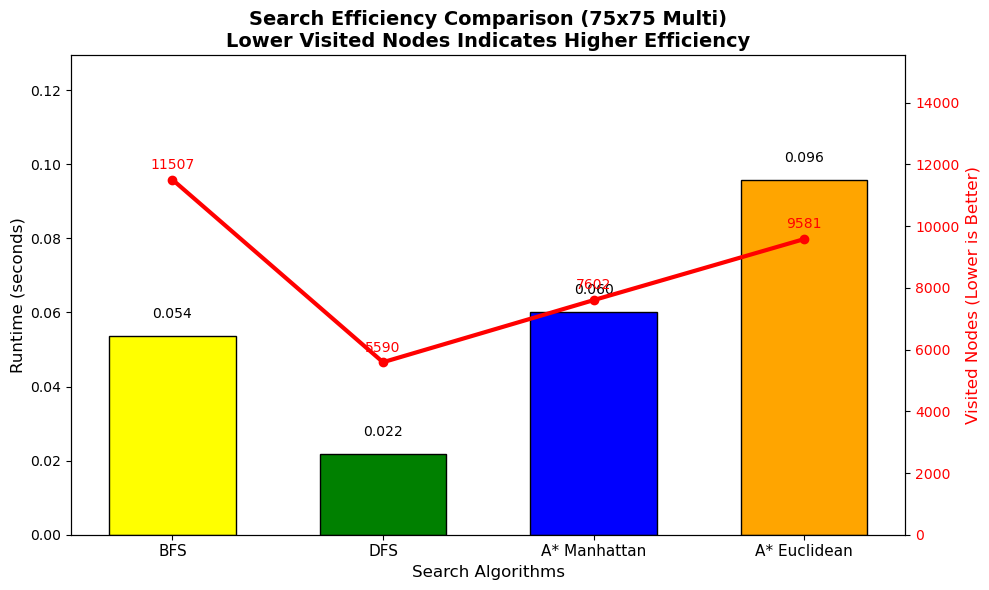

In [1]:
import matplotlib.pyplot as plt
import numpy as np

maze_data = {
    "20x20 Single": {
        "BFS":  {"runtime": 0.0037379999994300306, "visited": 788},
        "DFS":  {"runtime": 0.001443799992557615, "visited": 642},
        "A* Manhattan": {"runtime": 0.0008202000171877444, "visited": 175},
        "A* Euclidean": {"runtime": 0.0029473999748006463, "visited": 379},
    },
    "50x50 Single": {
        "BFS":  {"runtime": 0.01649179996456951, "visited": 3296},
        "DFS":  {"runtime": 0.017010600015055388, "visited": 3947},
        "A* Manhattan": {"runtime": 0.0079253000440076, "visited": 1263},
        "A* Euclidean": {"runtime": 0.015454799984581769, "visited": 1649},
    },
    "50x75 Single": {
        "BFS":  {"runtime": 0.03771990002132952, "visited": 6859},
        "DFS":  {"runtime": 0.024485800007823855, "visited": 6483},
        "A* Manhattan": {"runtime": 0.01657320000231266, "visited": 2239},
        "A* Euclidean": {"runtime": 0.02676799998153001, "visited": 2872},
    },
    "75x75 Single": {
        "BFS":  {"runtime": 0.049853499978780746, "visited": 11244},
        "DFS":  {"runtime": 0.03125190001446754, "visited": 7473},
        "A* Manhattan": {"runtime": 0.05832819995703176, "visited": 6825},
        "A* Euclidean": {"runtime": 0.08849380002357066, "visited": 8777},
    },
    "50x50 Multi": {
        "BFS":  {"runtime": 0.023503599979449064, "visited": 5032},
        "DFS":  {"runtime": 0.018335099972318858, "visited": 4377},
        "A* Manhattan": {"runtime": 0.022488899994641542, "visited": 3318},
        "A* Euclidean": {"runtime": 0.039709199976641685, "visited": 4000},
    },
    "75x75 Multi": {
        "BFS":  {"runtime": 0.05374689999734983, "visited": 11507},
        "DFS":  {"runtime": 0.021815899992361665, "visited": 5590},
        "A* Manhattan": {"runtime": 0.06014009995851666, "visited": 7602},
        "A* Euclidean": {"runtime": 0.09585819998756051, "visited": 9581},
    }
}
def plot_maze_chart(title, data):
    algorithms = list(data.keys())
    runtimes = [data[a]["runtime"] for a in algorithms]
    visited = [data[a]["visited"] for a in algorithms]
    x = np.arange(len(algorithms))
    width = 0.6
    fig, ax1 = plt.subplots(figsize=(10, 6))
    bars = ax1.bar(x, runtimes, width, color=["yellow", "green", "blue", "orange"], edgecolor="black")
    ax1.set_ylabel("Runtime (seconds)", fontsize=12)
    ax1.set_xlabel("Search Algorithms", fontsize=12)   
    ax1.set_xticks(x)
    ax1.set_xticklabels(algorithms, fontsize=11)
    max_runtime = max(runtimes)
    ax1.set_ylim(0, max_runtime * 1.35)
    ax2 = ax1.twinx()
    ax2.plot(x, visited, color="red", marker="o", linewidth=3)
    ax2.set_ylabel("Visited Nodes (Lower is Better)", color="red", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="red")
    max_visited = max(visited)
    ax2.set_ylim(0, max_visited * 1.35)
    plt.title(
        f"Search Efficiency Comparison ({title})\nLower Visited Nodes Indicates Higher Efficiency",
        fontsize=14,
        fontweight="bold"
    )
    for i, v in enumerate(runtimes):
        ax1.text(i, v + max_runtime * 0.05, f"{v:.3f}", ha="center", fontsize=10)
    for i, v in enumerate(visited):
        ax2.text(i, v + max_visited * 0.03, f"{v}", color="red", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()
for maze_name, data in maze_data.items():
    plot_maze_chart(maze_name, data)

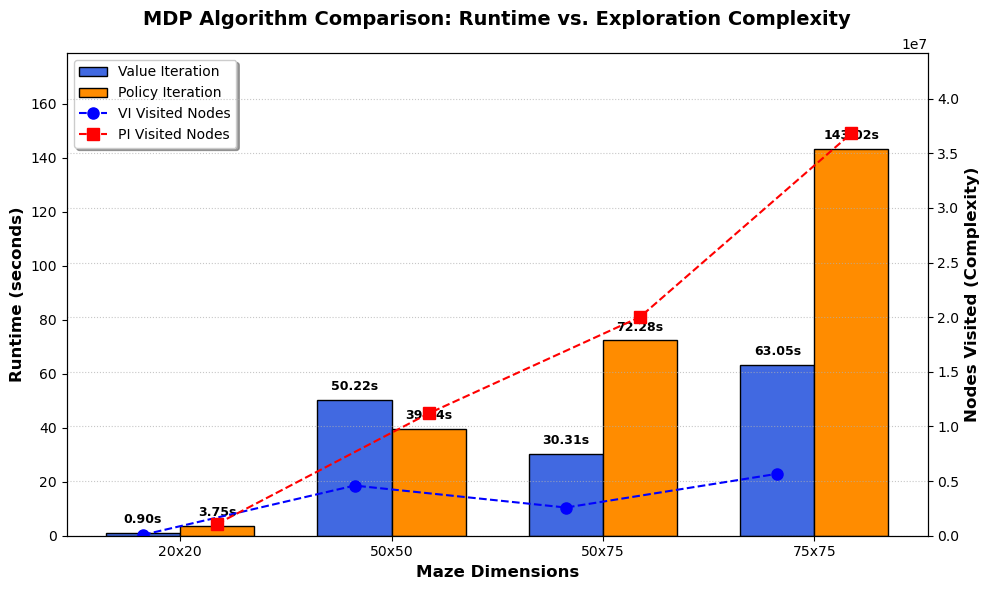

In [2]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['20x20', '50x50', '50x75', '75x75']
vi_runtime = [
    0.9036143999546766,   
    50.21772659989074,    
    30.30605320003815,    
    63.054887499893084    
]
pi_runtime = [
    3.748589999973774,    
    39.440153300063685,   
    72.28337299986742,    
    143.02282719989307    
]
vi_visited = [
    81498,        
    4589082,      
    2579312,      
    5668992       
]
pi_visited = [
    1077851,      
    11187762,     
    20012162,     
    36825952      
]
x = np.arange(len(labels))
width = 0.35
fig, ax1 = plt.subplots(figsize=(10, 6))
bars1 = ax1.bar(x - width/2, vi_runtime, width, label='Value Iteration', color='#4169E1', edgecolor='black')
bars2 = ax1.bar(x + width/2, pi_runtime, width, label='Policy Iteration', color='#FF8C00', edgecolor='black')
ax1.set_xlabel('Maze Dimensions', fontsize=12, fontweight='bold')
ax1.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, max(pi_runtime) * 1.25)
ax2 = ax1.twinx()
ax2.plot(x - width/2, vi_visited, color='blue', marker='o', markersize=8, linestyle='--', label='VI Visited Nodes')
ax2.plot(x + width/2, pi_visited, color='red', marker='s', markersize=8, linestyle='--', label='PI Visited Nodes')
ax2.set_ylabel('Nodes Visited (Complexity)', color='black', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(pi_visited) * 1.2)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.2f}s',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold', fontsize=9)

autolabel(bars1)
autolabel(bars2)
plt.title('MDP Algorithm Comparison: Runtime vs. Exploration Complexity', fontsize=14, fontweight='bold', pad=20)
lines, labels_lines = ax1.get_legend_handles_labels()
lines2, labels_lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_lines + labels_lines2, loc='upper left', frameon=True, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

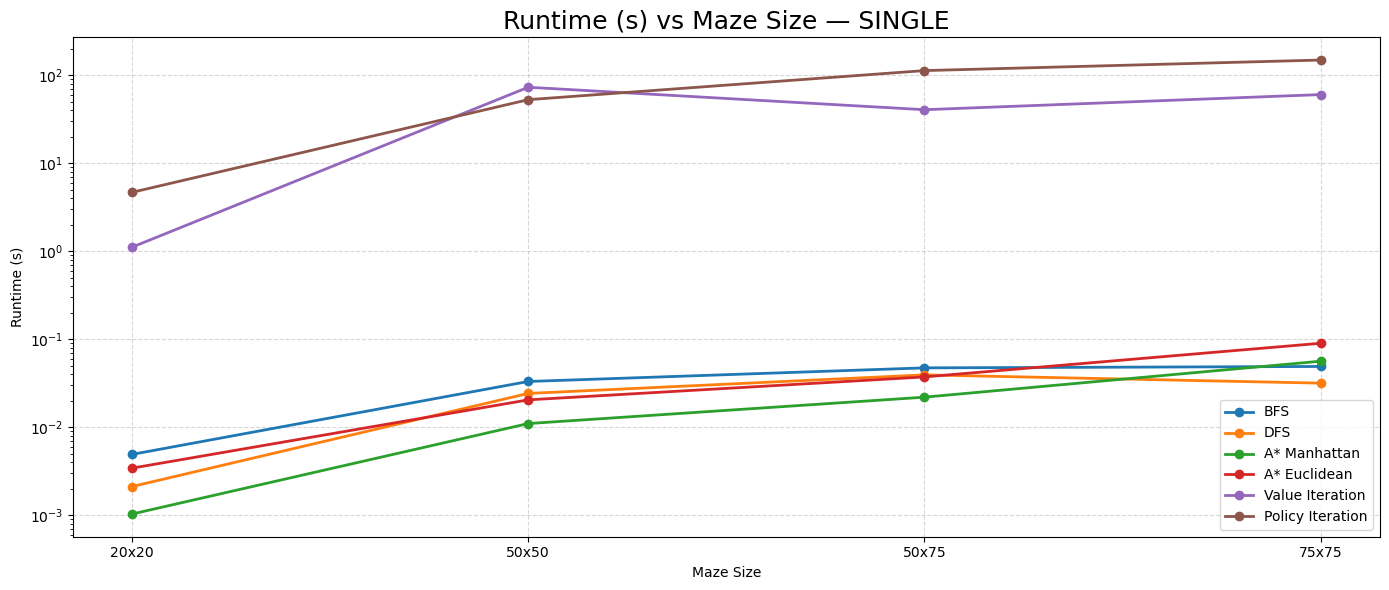

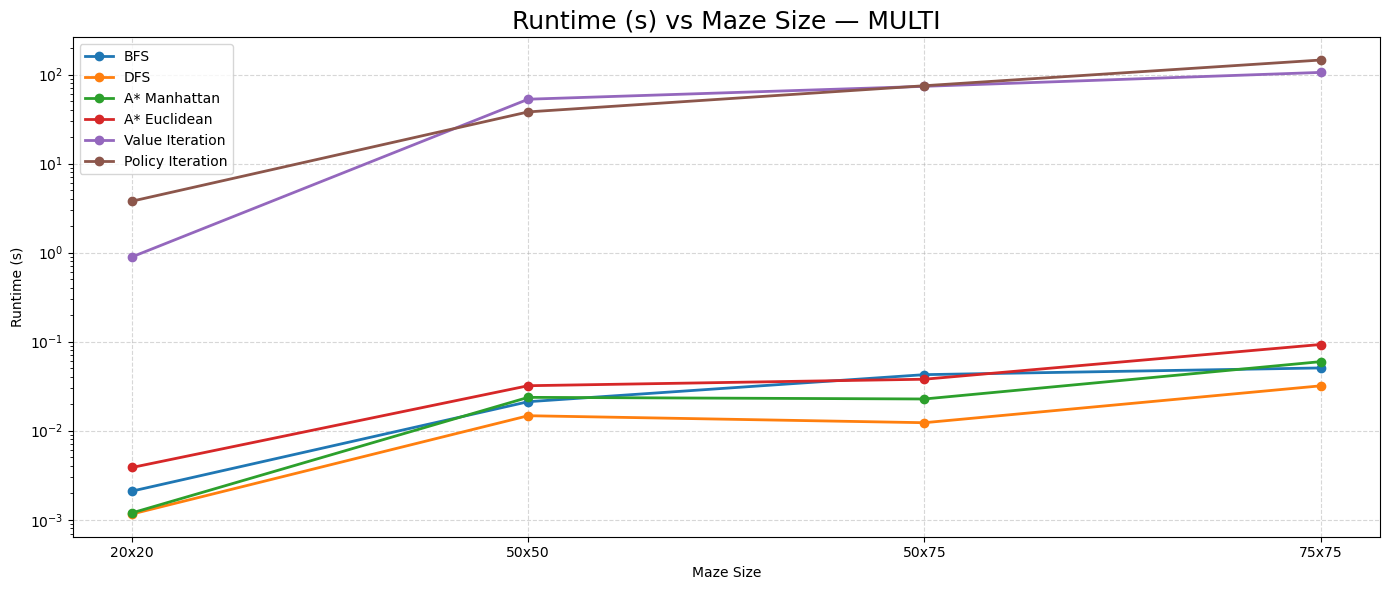

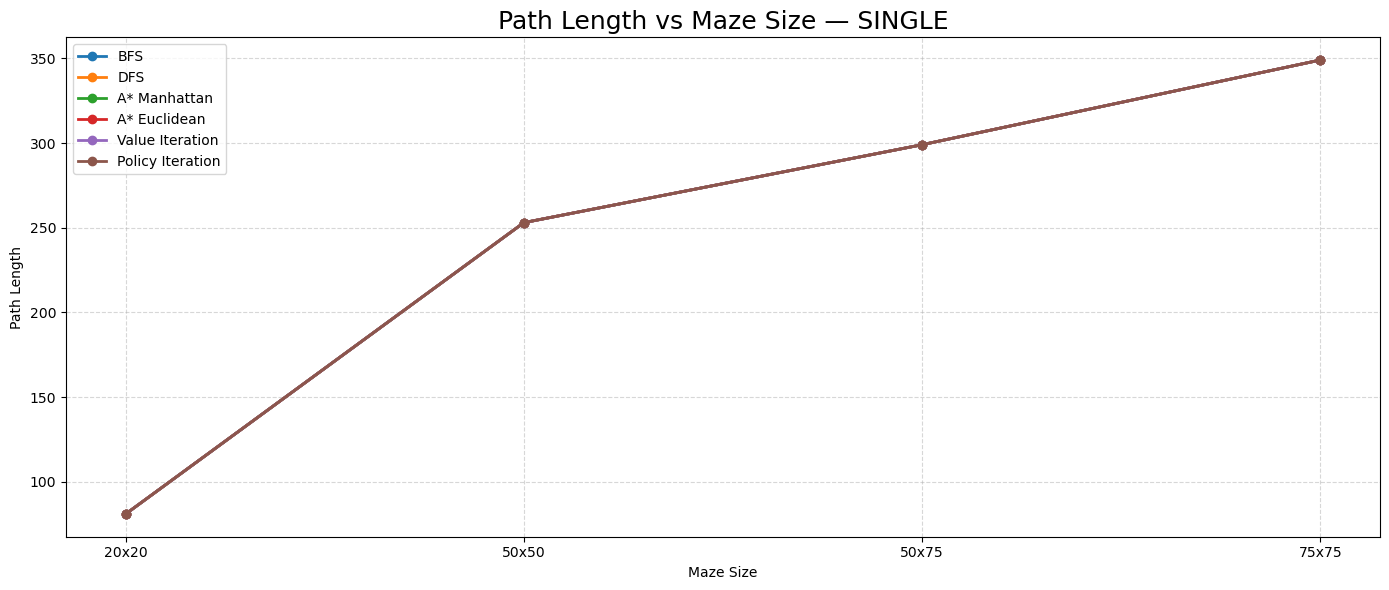

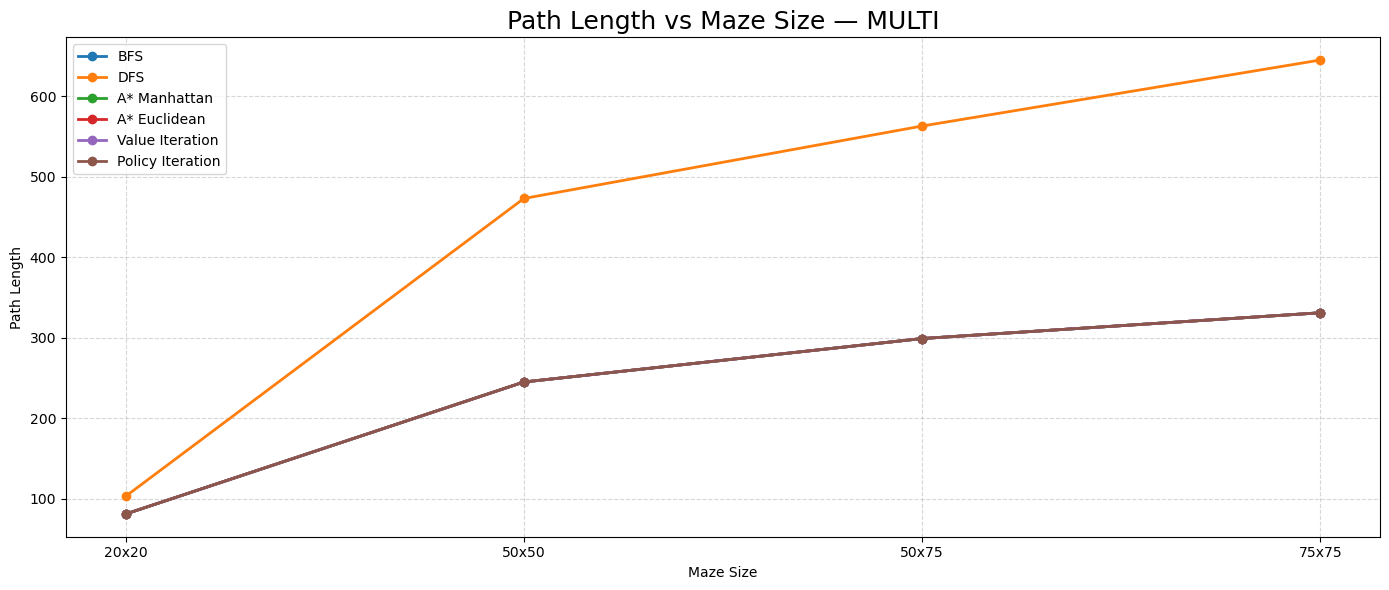

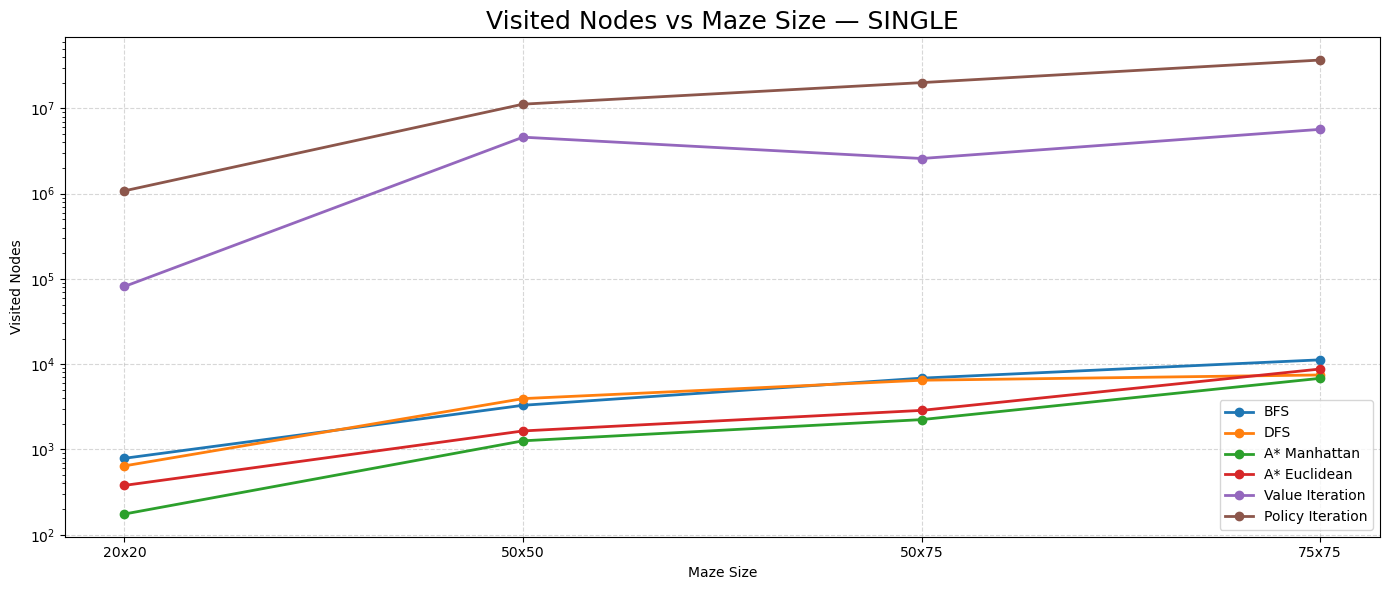

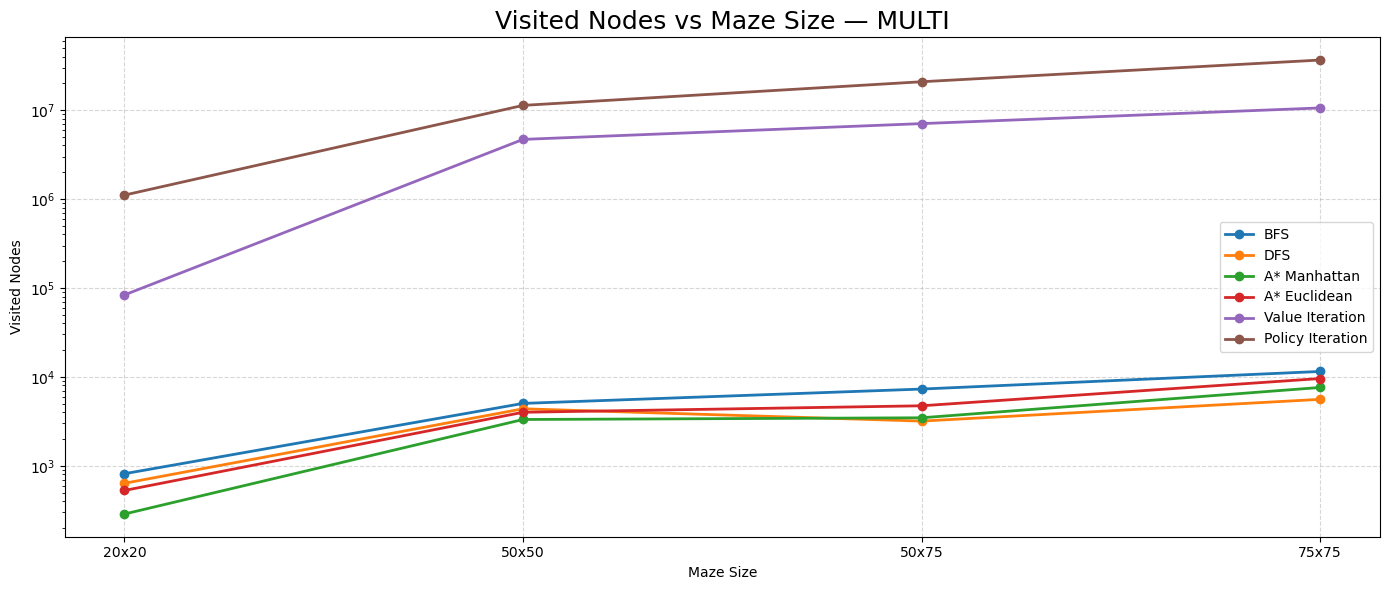

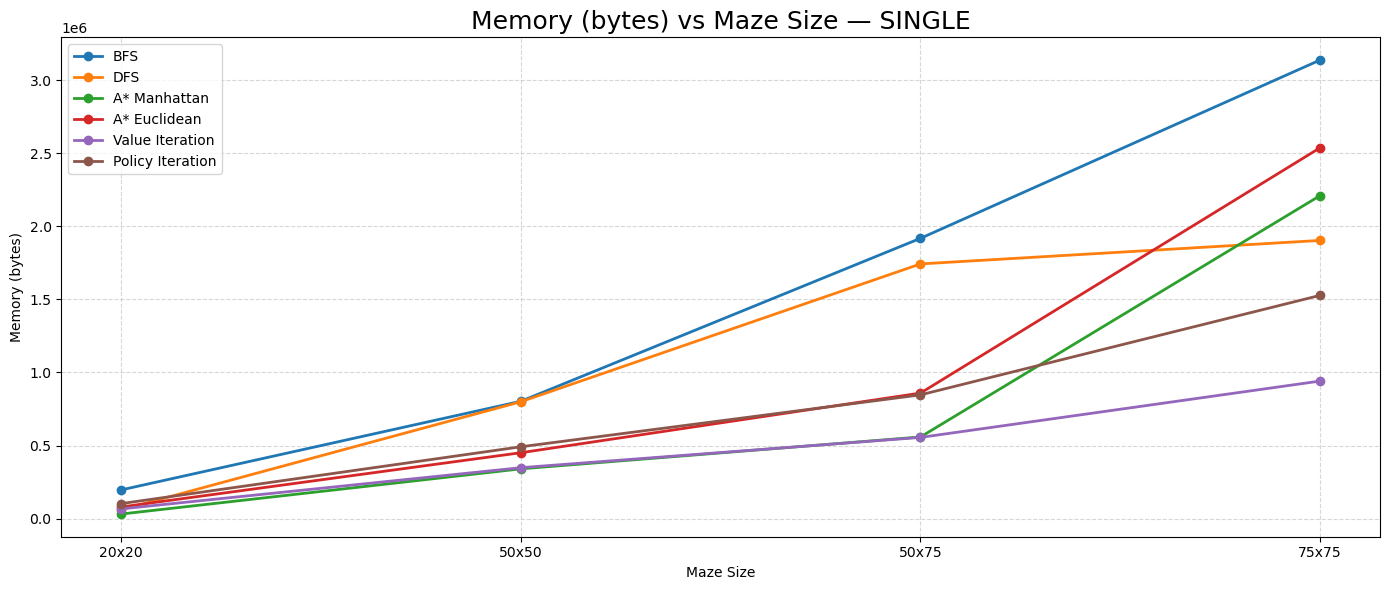

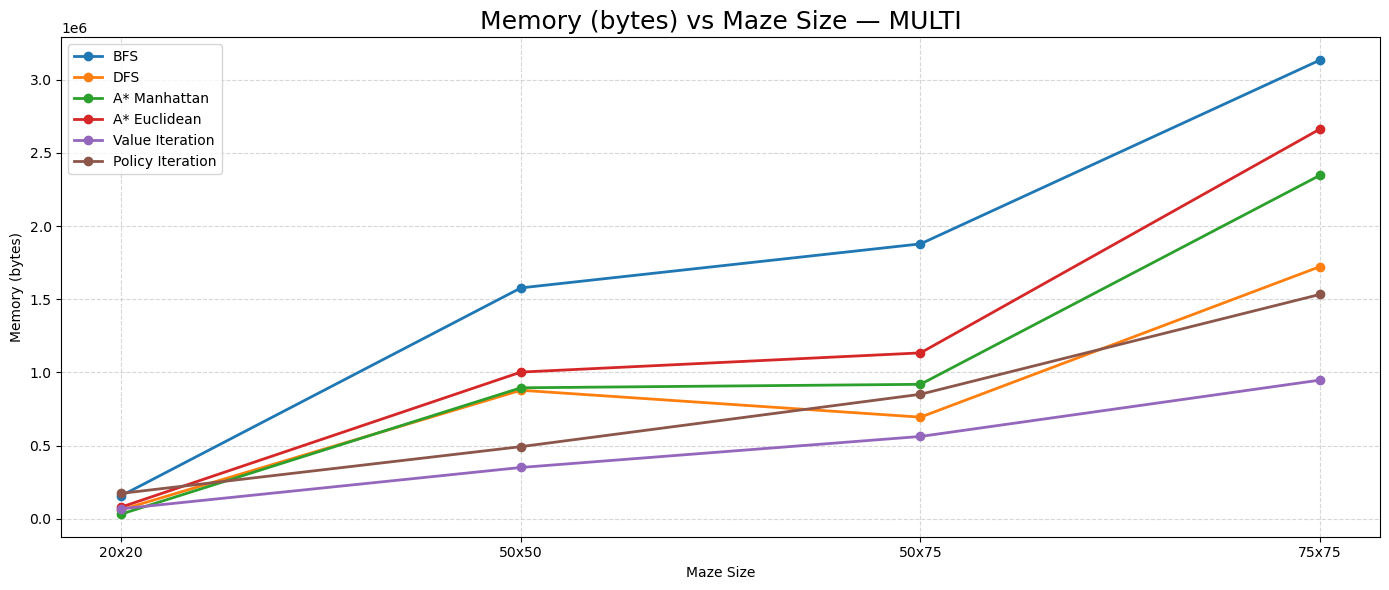

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def jitter(values, amount=3):
    """Adds vertical jitter so identical lines become visible."""
    values = np.array(values, dtype=float)
    jittered = values + np.random.uniform(-amount, amount, size=len(values))
    return jittered
data = {
    "20x20": {
        "Single": {
            "BFS": (0.004911000141873956, 81, 788, 197036),
            "DFS": (0.002116299932822585, 81, 642, 60892),
            "A* Manhattan": (0.0010306001640856266, 81, 175, 31840),
            "A* Euclidean": (0.003426400013267994, 81, 379, 80228),
            "Value Iteration": (1.1148688001558185, 81, 81498, 67141),
            "Policy Iteration": (4.686080100014806, 81, 1077851, 103237)
        },
        "Multi": {
            "BFS": (0.0020955000072717667, 81, 815, 157188),
            "DFS": (0.0011585999745875597, 103, 636, 61084),
            "A* Manhattan": (0.0011928998865187168, 81, 287, 31840),
            "A* Euclidean": (0.0038618999533355236, 81, 528, 79508),
            "Value Iteration": (0.8968739002011716, 81, 83436, 67601),
            "Policy Iteration": (3.789012100081891, 81, 1105936, 173154)
        }
    },
    "50x50": {
        "Single": {
            "BFS": (0.03312829998321831, 253, 3296, 803356),
            "DFS": (0.02422249992378056, 253, 3947, 800084),
            "A* Manhattan": (0.01100850012153387, 253, 1263, 340964),
            "A* Euclidean": (0.020476900041103363, 253, 1649, 451252),
            "Value Iteration": (73.40972590004094, 253, 4589082, 348909),
            "Policy Iteration": (53.01954620005563, 253, 11187762, 491964)
        },
        "Multi": {
            "BFS": (0.021171400090679526, 245, 5032, 1577772),
            "DFS": (0.014730900060385466, 473, 4377, 877964),
            "A* Manhattan": (0.023691099835559726, 245, 3318, 894760),
            "A* Euclidean": (0.032013599993661046, 245, 4000, 1002154),
            "Value Iteration": (52.94398669991642, 245, 4680882, 350091),
            "Policy Iteration": (38.13255670014769, 245, 11289186, 492449)
        }
    },
    "50x75": {
        "Single": {
            "BFS": (0.047300799982622266, 299, 6859, 1917871),
            "DFS": (0.039370200131088495, 299, 6483, 1742716),
            "A* Manhattan": (0.021966399857774377, 299, 2239, 559020),
            "A* Euclidean": (0.03732139989733696, 299, 2872, 859140),
            "Value Iteration": (40.764925400028005, 299, 2579312, 555936),
            "Policy Iteration": (113.52704489999451, 299, 20012162, 846943)
        },
        "Multi": {
            "BFS": (0.042616300052031875, 299, 7295, 1878628),
            "DFS": (0.012296600034460425, 563, 3182, 694196),
            "A* Manhattan": (0.022712199948728085, 299, 3467, 918548),
            "A* Euclidean": (0.03786539984866977, 299, 4730, 1133348),
            "Value Iteration": (73.8601935999468, 299, 7042896, 562208),
            "Policy Iteration": (75.01947050006129, 299, 20821808, 850505)
        }
    },
    "75x75": {
        "Single": {
            "BFS": (0.049074900103732944, 349, 11244, 3137436),
            "DFS": (0.03171579982154071, 349, 7473, 1903492),
            "A* Manhattan": (0.05632089986465871, 349, 6825, 2209892),
            "A* Euclidean": (0.09007810009643435, 349, 8777, 2537170),
            "Value Iteration": (60.567037999862805, 349, 5668992, 941335),
            "Policy Iteration": (149.6686868998222, 349, 36825952, 1527563)
        },
        "Multi": {
            "BFS": (0.05069709988310933, 331, 11507, 3135438),
            "DFS": (0.031909799901768565, 645, 5590, 1723324),
            "A* Manhattan": (0.05964599992148578, 331, 7602, 2347934),
            "A* Euclidean": (0.09295459999702871, 331, 9581, 2664026),
            "Value Iteration": (105.91976540000178, 331, 10568016, 947455),
            "Policy Iteration": (145.84122629999183, 331, 36527576, 1533320)
        }
    }
}
def plot_metric(metric_index, metric_name):
    maze_sizes = list(data.keys())
    algorithms = list(data["20x20"]["Single"].keys())
    plt.figure(figsize=(14, 6))
    plt.title(f"{metric_name} vs Maze Size — SINGLE", fontsize=18)
    for algo in algorithms:
        y = [data[maze]["Single"][algo][metric_index] for maze in maze_sizes]
        if len(set(y)) == 1:
            y = jitter(y, amount=3)
        plt.plot(maze_sizes, y, marker="o", linewidth=2, label=algo)
    if metric_name in ["Runtime (s)", "Visited Nodes"]:
        plt.yscale("log")
    plt.xlabel("Maze Size")
    plt.ylabel(metric_name)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(14, 6))
    plt.title(f"{metric_name} vs Maze Size — MULTI", fontsize=18)
    for algo in algorithms:
        y = []
        for maze in maze_sizes:
            if "Multi" in data[maze] and algo in data[maze]["Multi"]:
                y.append(data[maze]["Multi"][algo][metric_index])
            else:
                y.append(np.nan)

        plt.plot(maze_sizes, y, marker="o", linewidth=2, label=algo)
    if metric_name in ["Runtime (s)", "Visited Nodes"]:
        plt.yscale("log")
    plt.xlabel("Maze Size")
    plt.ylabel(metric_name)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_metric(0, "Runtime (s)")
plot_metric(1, "Path Length")
plot_metric(2, "Visited Nodes")
plot_metric(3, "Memory (bytes)")